# Submission Pertama: Menyelesaikan Permasalahan Human Resources Perusahaan Jaya Jaya Maju

- Nama: Dewa Bagus Putu Arya Dhananjaya
- Email: dewadhanan@gmail.com
- Id Dicoding: dewadhanan25

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Import Library Utama
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Setup
warnings.filterwarnings("ignore")

### Menyiapkan data yang akan digunakan

## Data Understanding

In [2]:
df = pd.read_csv('employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [4]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.duplicated().sum()
print(f'Number of duplicate data: {df.duplicated().sum()}')

Number of duplicate data: 0


In [6]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [7]:
check_missing_value = df.isnull().sum()

# Tampilkan hanya kolom yang punya missing value > 0
print((check_missing_value[check_missing_value > 0]))

Attrition    412
dtype: int64


## Data Preparation / Preprocessing

In [8]:
# Menghapus baris yang memiliki nilai kosong (NaN) pada kolom 'Attrition'
df.dropna(subset=['Attrition'], inplace=True)

df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [9]:
# Menghapus kolom yang tidak informatif
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']
df.drop(columns=cols_to_drop, inplace=True)

df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,3,1,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,3,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,3,...,3,4,1,23,2,4,20,4,4,8
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,2,...,4,3,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,4,...,3,4,1,24,2,3,5,2,1,4


In [10]:
df_cleaned = df.copy()
df_cleaned.to_csv('employee_data_cleaned.csv', index=False)

df_cleaned.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,3,1,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,3,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,3,...,3,4,1,23,2,4,20,4,4,8
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,2,...,4,3,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,4,...,3,4,1,24,2,3,5,2,1,4


In [11]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1058 non-null   int64  
 1   Age                       1058 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1058 non-null   object 
 4   DailyRate                 1058 non-null   int64  
 5   Department                1058 non-null   object 
 6   DistanceFromHome          1058 non-null   int64  
 7   Education                 1058 non-null   int64  
 8   EducationField            1058 non-null   object 
 9   EnvironmentSatisfaction   1058 non-null   int64  
 10  Gender                    1058 non-null   object 
 11  HourlyRate                1058 non-null   int64  
 12  JobInvolvement            1058 non-null   int64  
 13  JobLevel                  1058 non-null   int64  
 14  JobRole      

Total Number of Employees: 1058
Are there any duplicate Employee IDs?: False


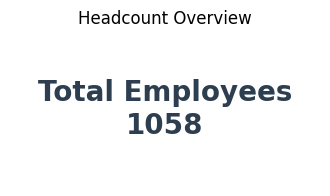

In [12]:
# Menghitung jumlah total karyawan berdasarkan EmployeeId unik
total_employees = df['EmployeeId'].nunique()

print(f"Total Number of Employees: {total_employees}")

# Mengecek apakah ada EmployeeId yang duplikat
is_duplicate = df['EmployeeId'].duplicated().any()
print(f"Are there any duplicate Employee IDs?: {is_duplicate}")

# Visualisasi
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f'Total Employees\n{total_employees}',
         fontsize=20, fontweight='bold', ha='center', va='center', color='#2c3e50')
plt.axis('off')
plt.title('Headcount Overview', fontsize=12)
plt.show()

Total Attrition:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64

Attrition Percentage:
Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64


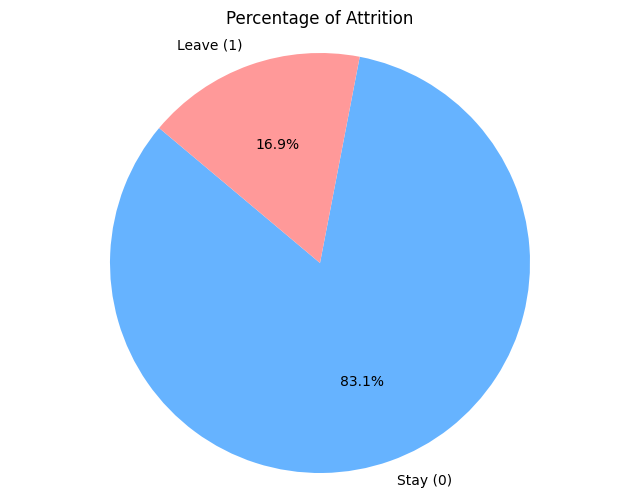

In [13]:
# Hitung jumlah dan persentase attrition
attrition_counts = df_cleaned['Attrition'].value_counts()
attrition_percentage = df_cleaned['Attrition'].value_counts(normalize=True) * 100

print("Total Attrition:")
print(attrition_counts)

print("\nAttrition Percentage:")
print(attrition_percentage)

# Ubah label 0 dan 1 menjadi lebih deskriptif
labels = ['Stay (0)', 'Leave (1)']

# Pastikan urutan sesuai dengan index (0 dan 1)
attrition_counts = attrition_counts.sort_index()

# Visualisasi dengan Pie Chart untuk melihat proporsi
plt.figure(figsize=(8, 6))
plt.pie(
    attrition_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff','#ff9999']
)
plt.title('Percentage of Attrition')
plt.axis('equal')
plt.show()

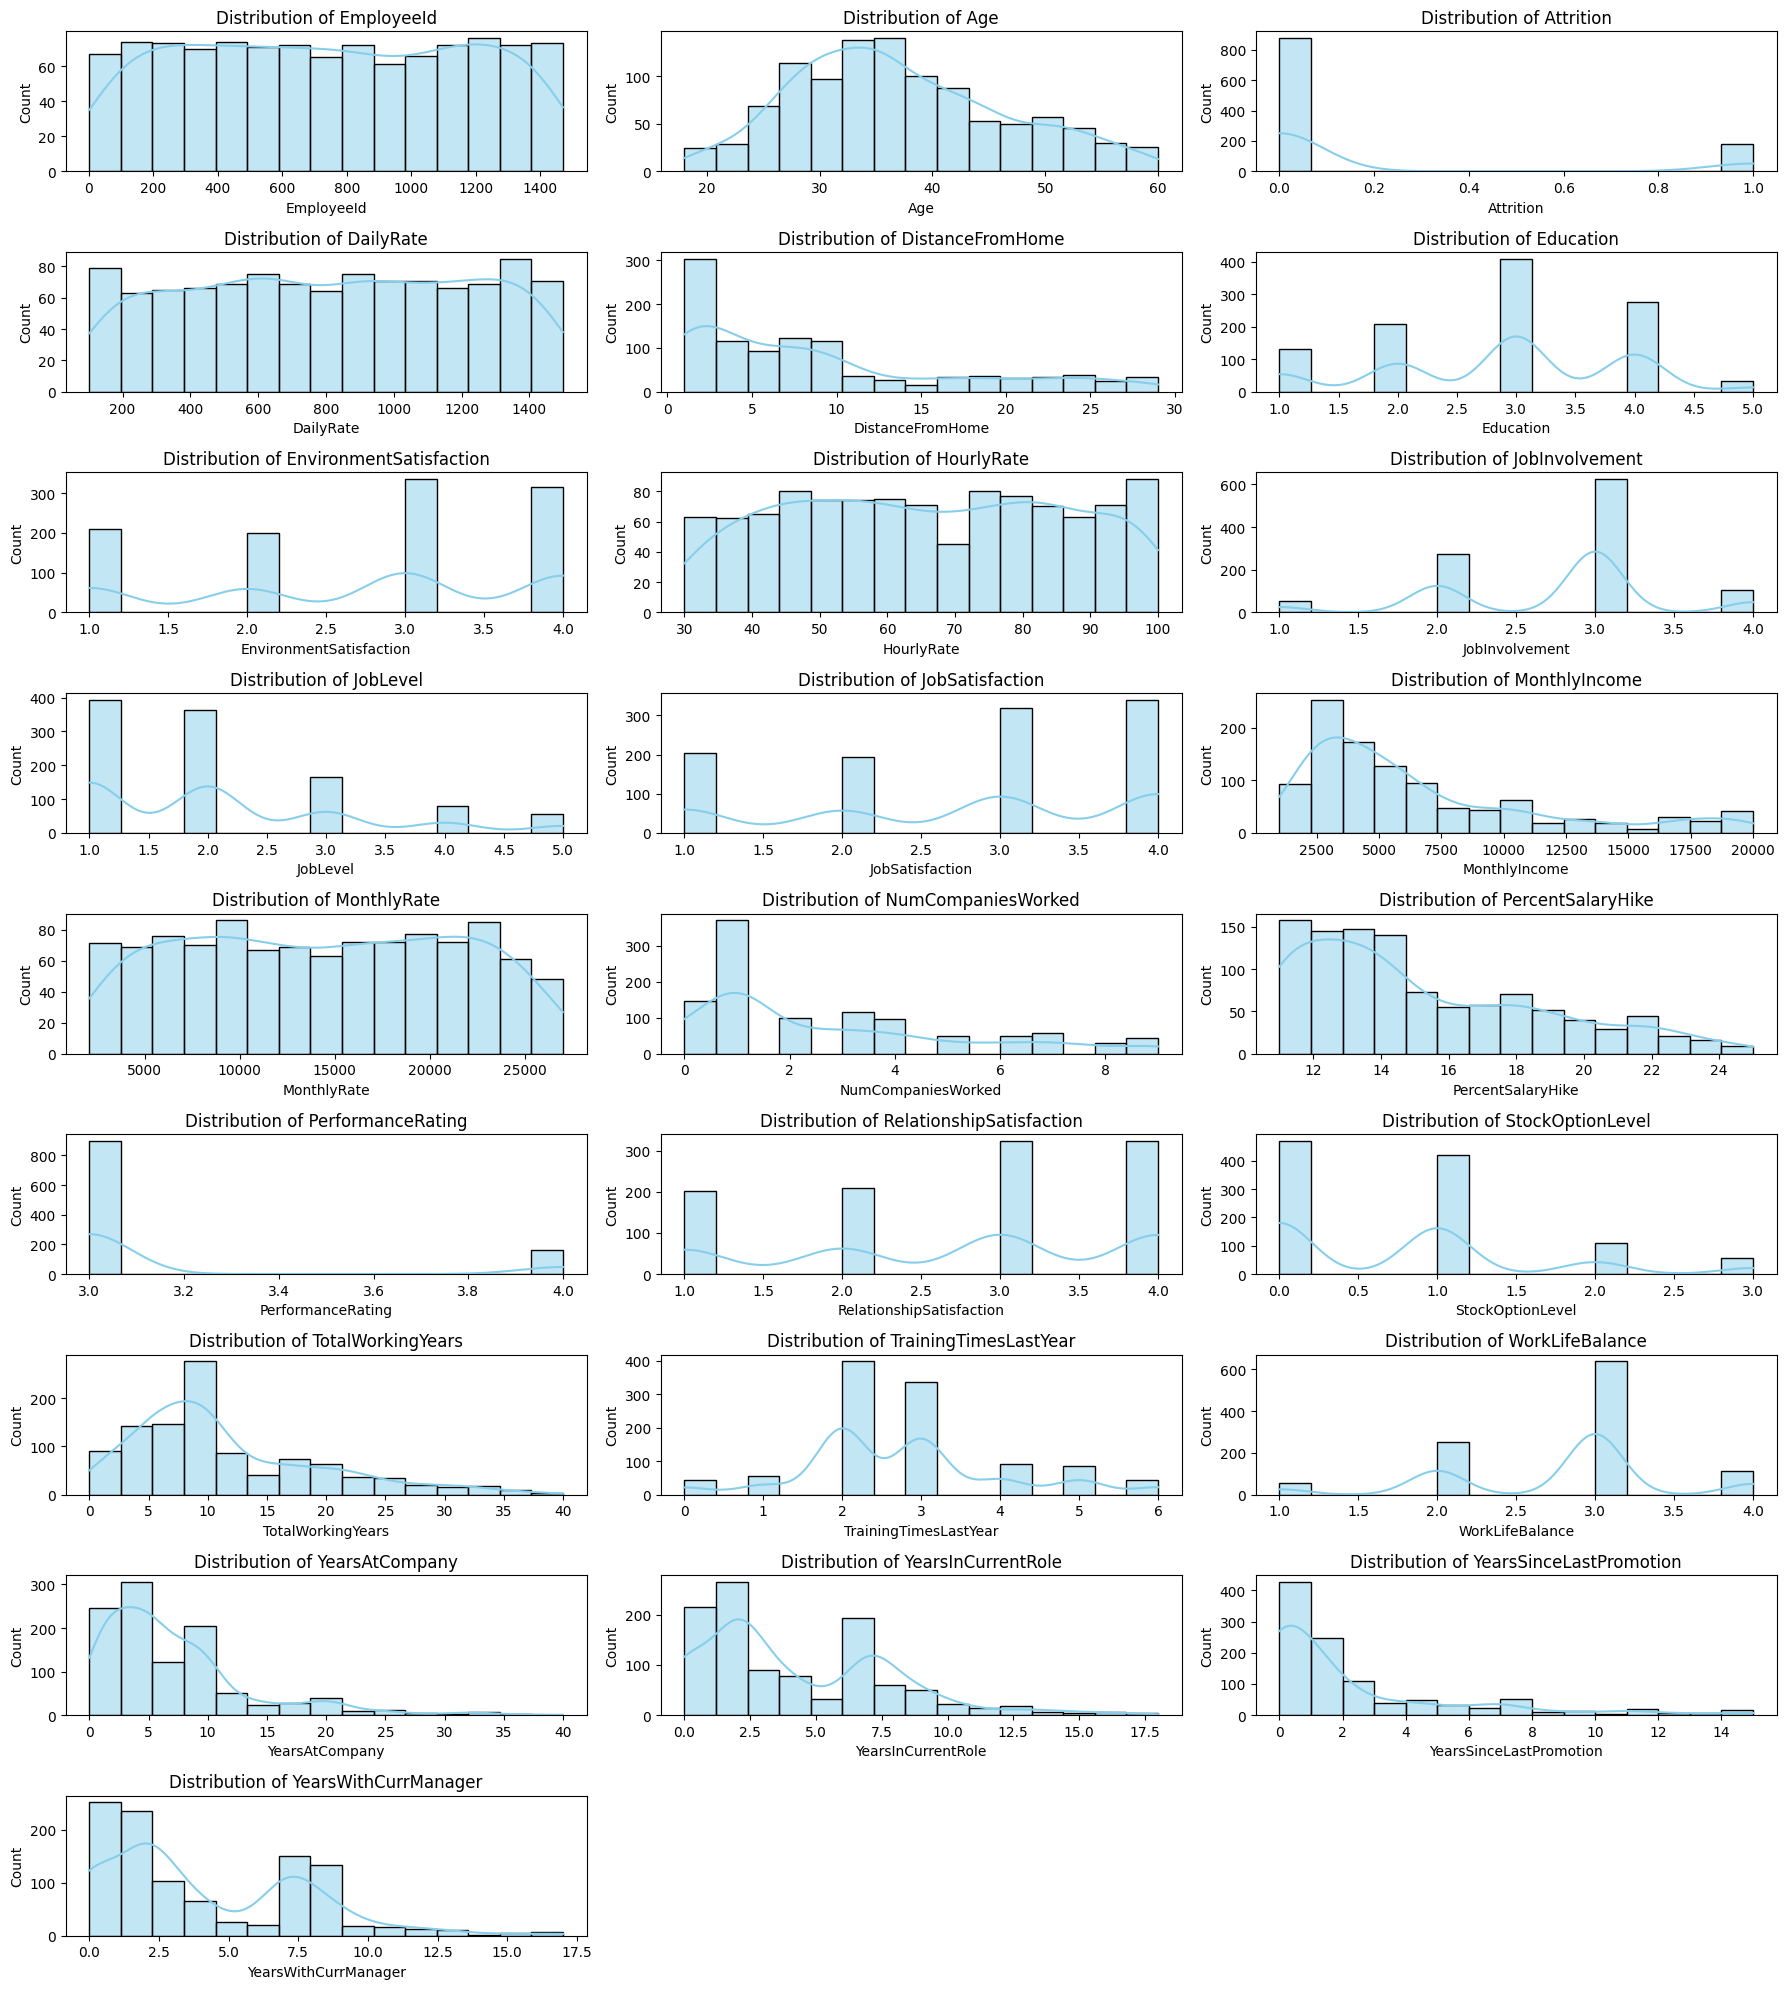

In [14]:
# Pilih semua kolom numerik (int64 dan float64)
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Atur ukuran canvas
plt.figure(figsize=(18, 20))

# Loop setiap kolom numerik
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.histplot(df_cleaned[col], kde=True, bins=15, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

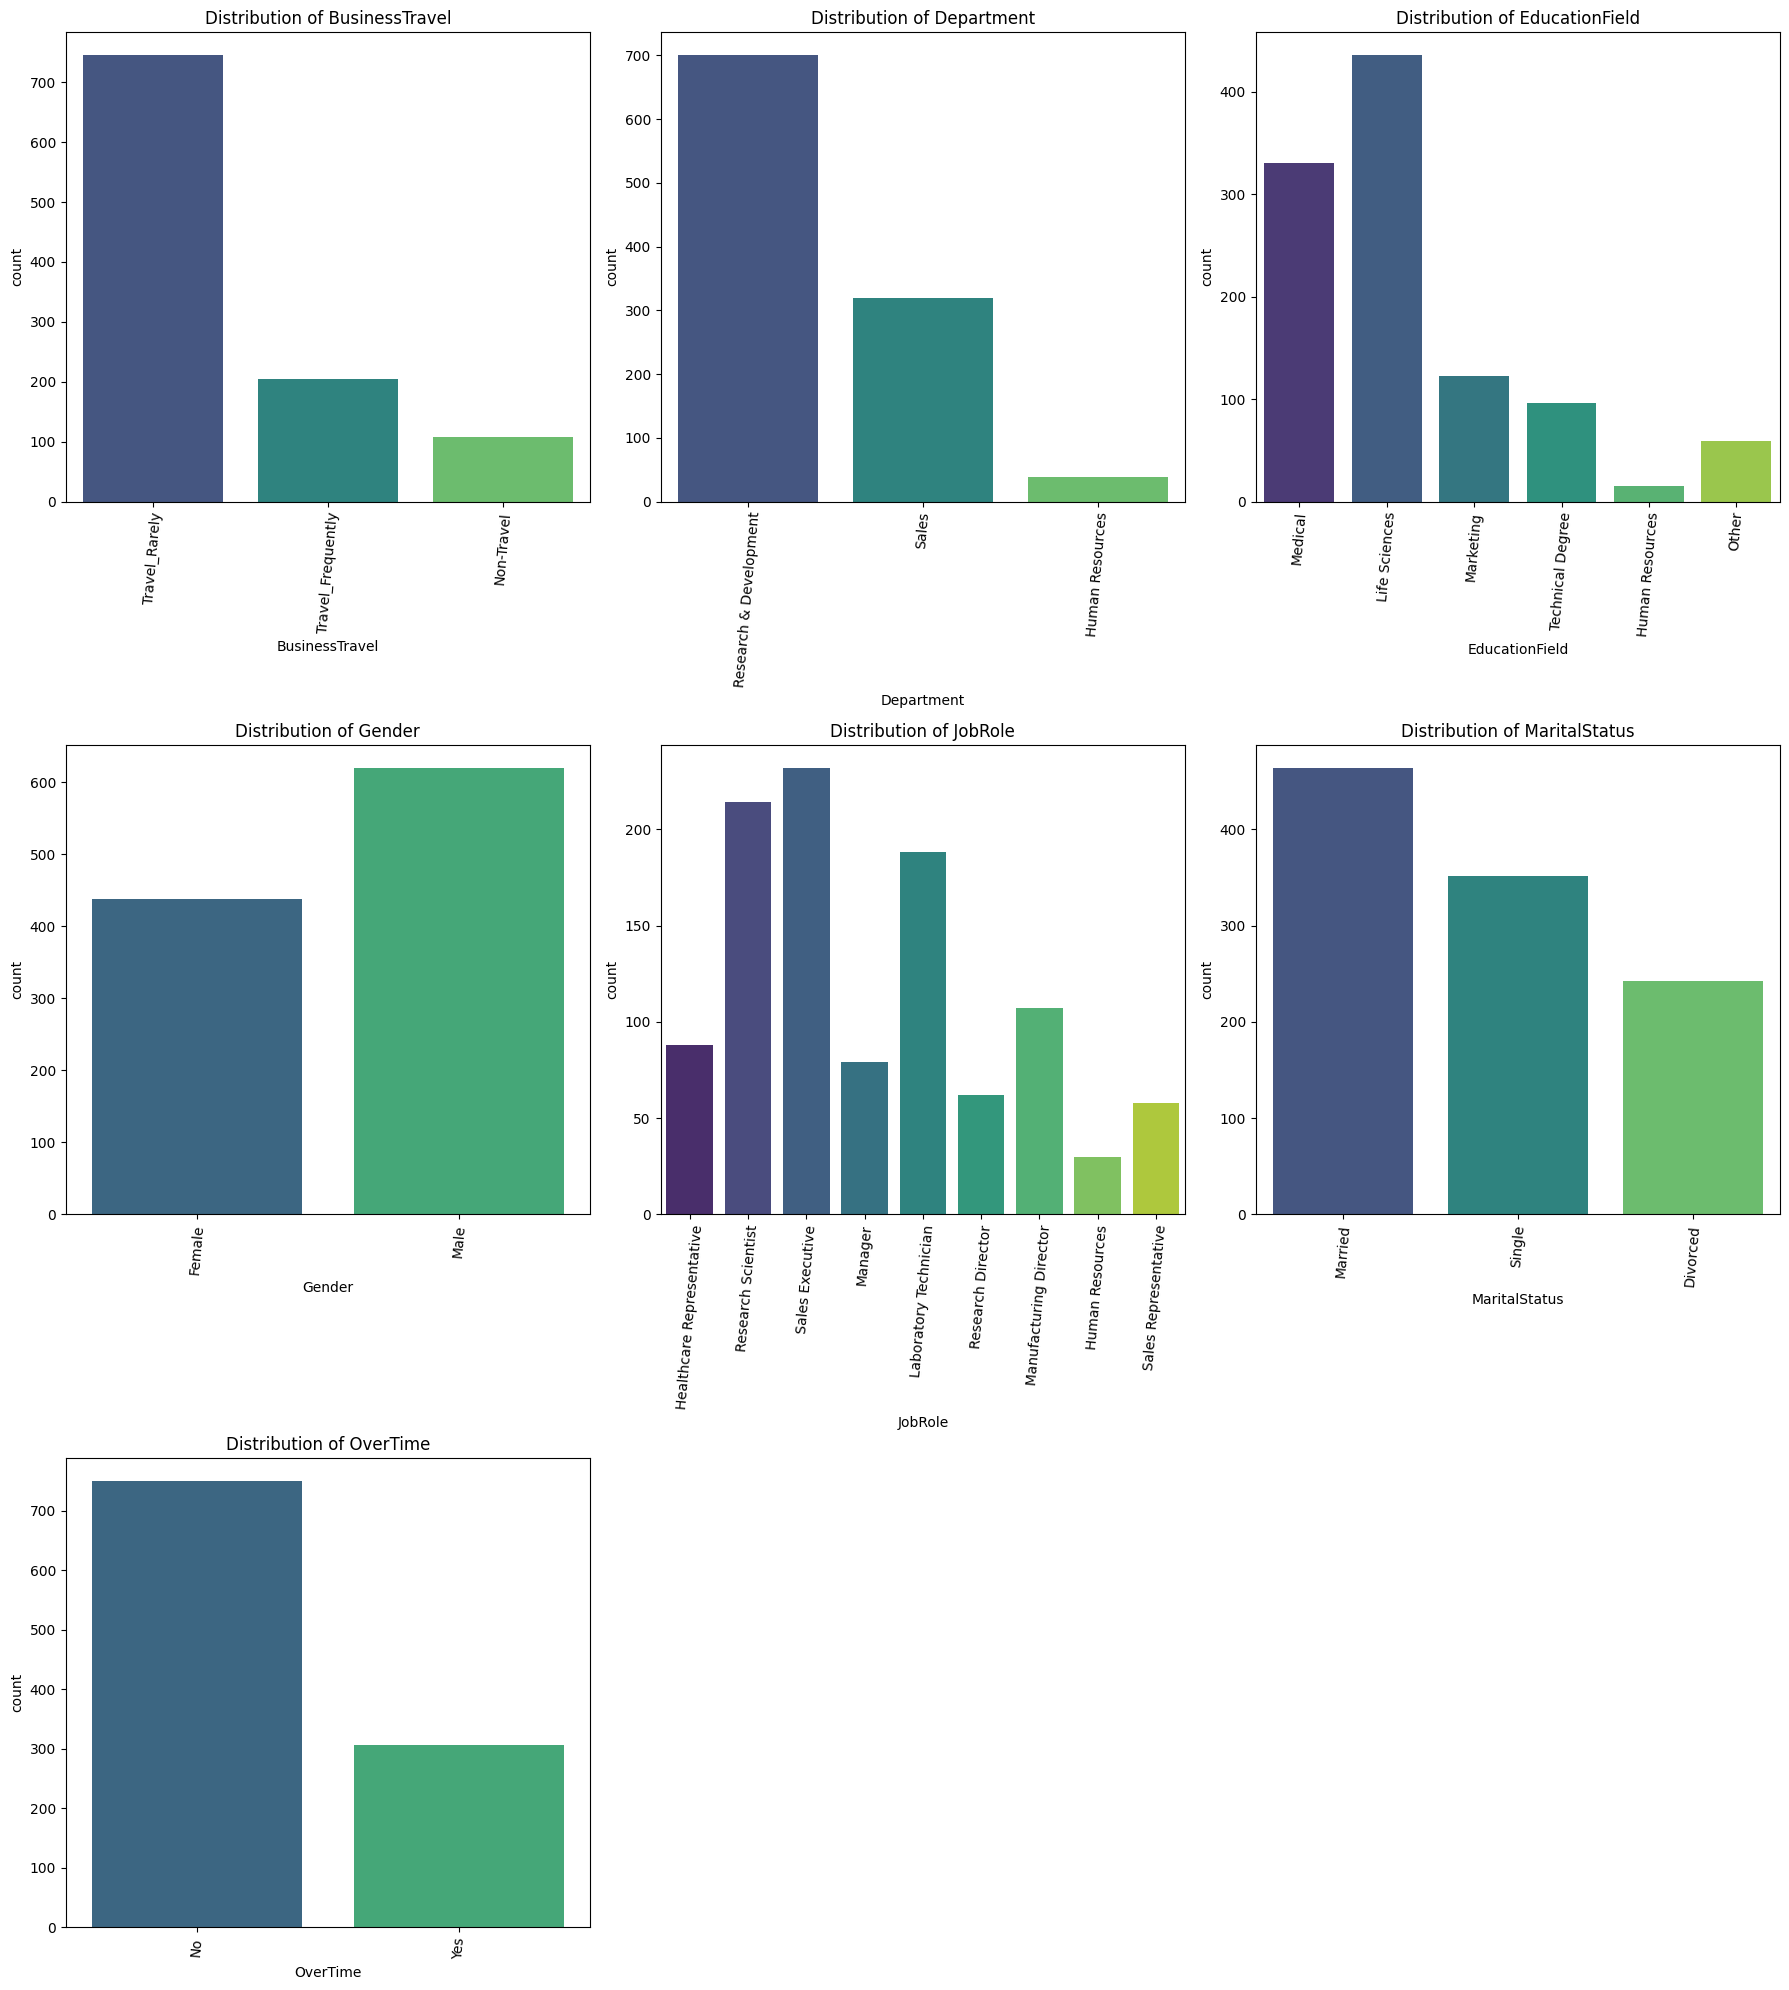

In [15]:
# Pilih semua kolom bertipe kategorikal (object atau string)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Atur ukuran canvas
plt.figure(figsize=(18, 20))

# Loop setiap kolom kategorikal
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols) // 3 + 1, 3, i)
    sns.countplot(data=df_cleaned, x=col, palette="viridis")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=85)

plt.tight_layout()
plt.show()

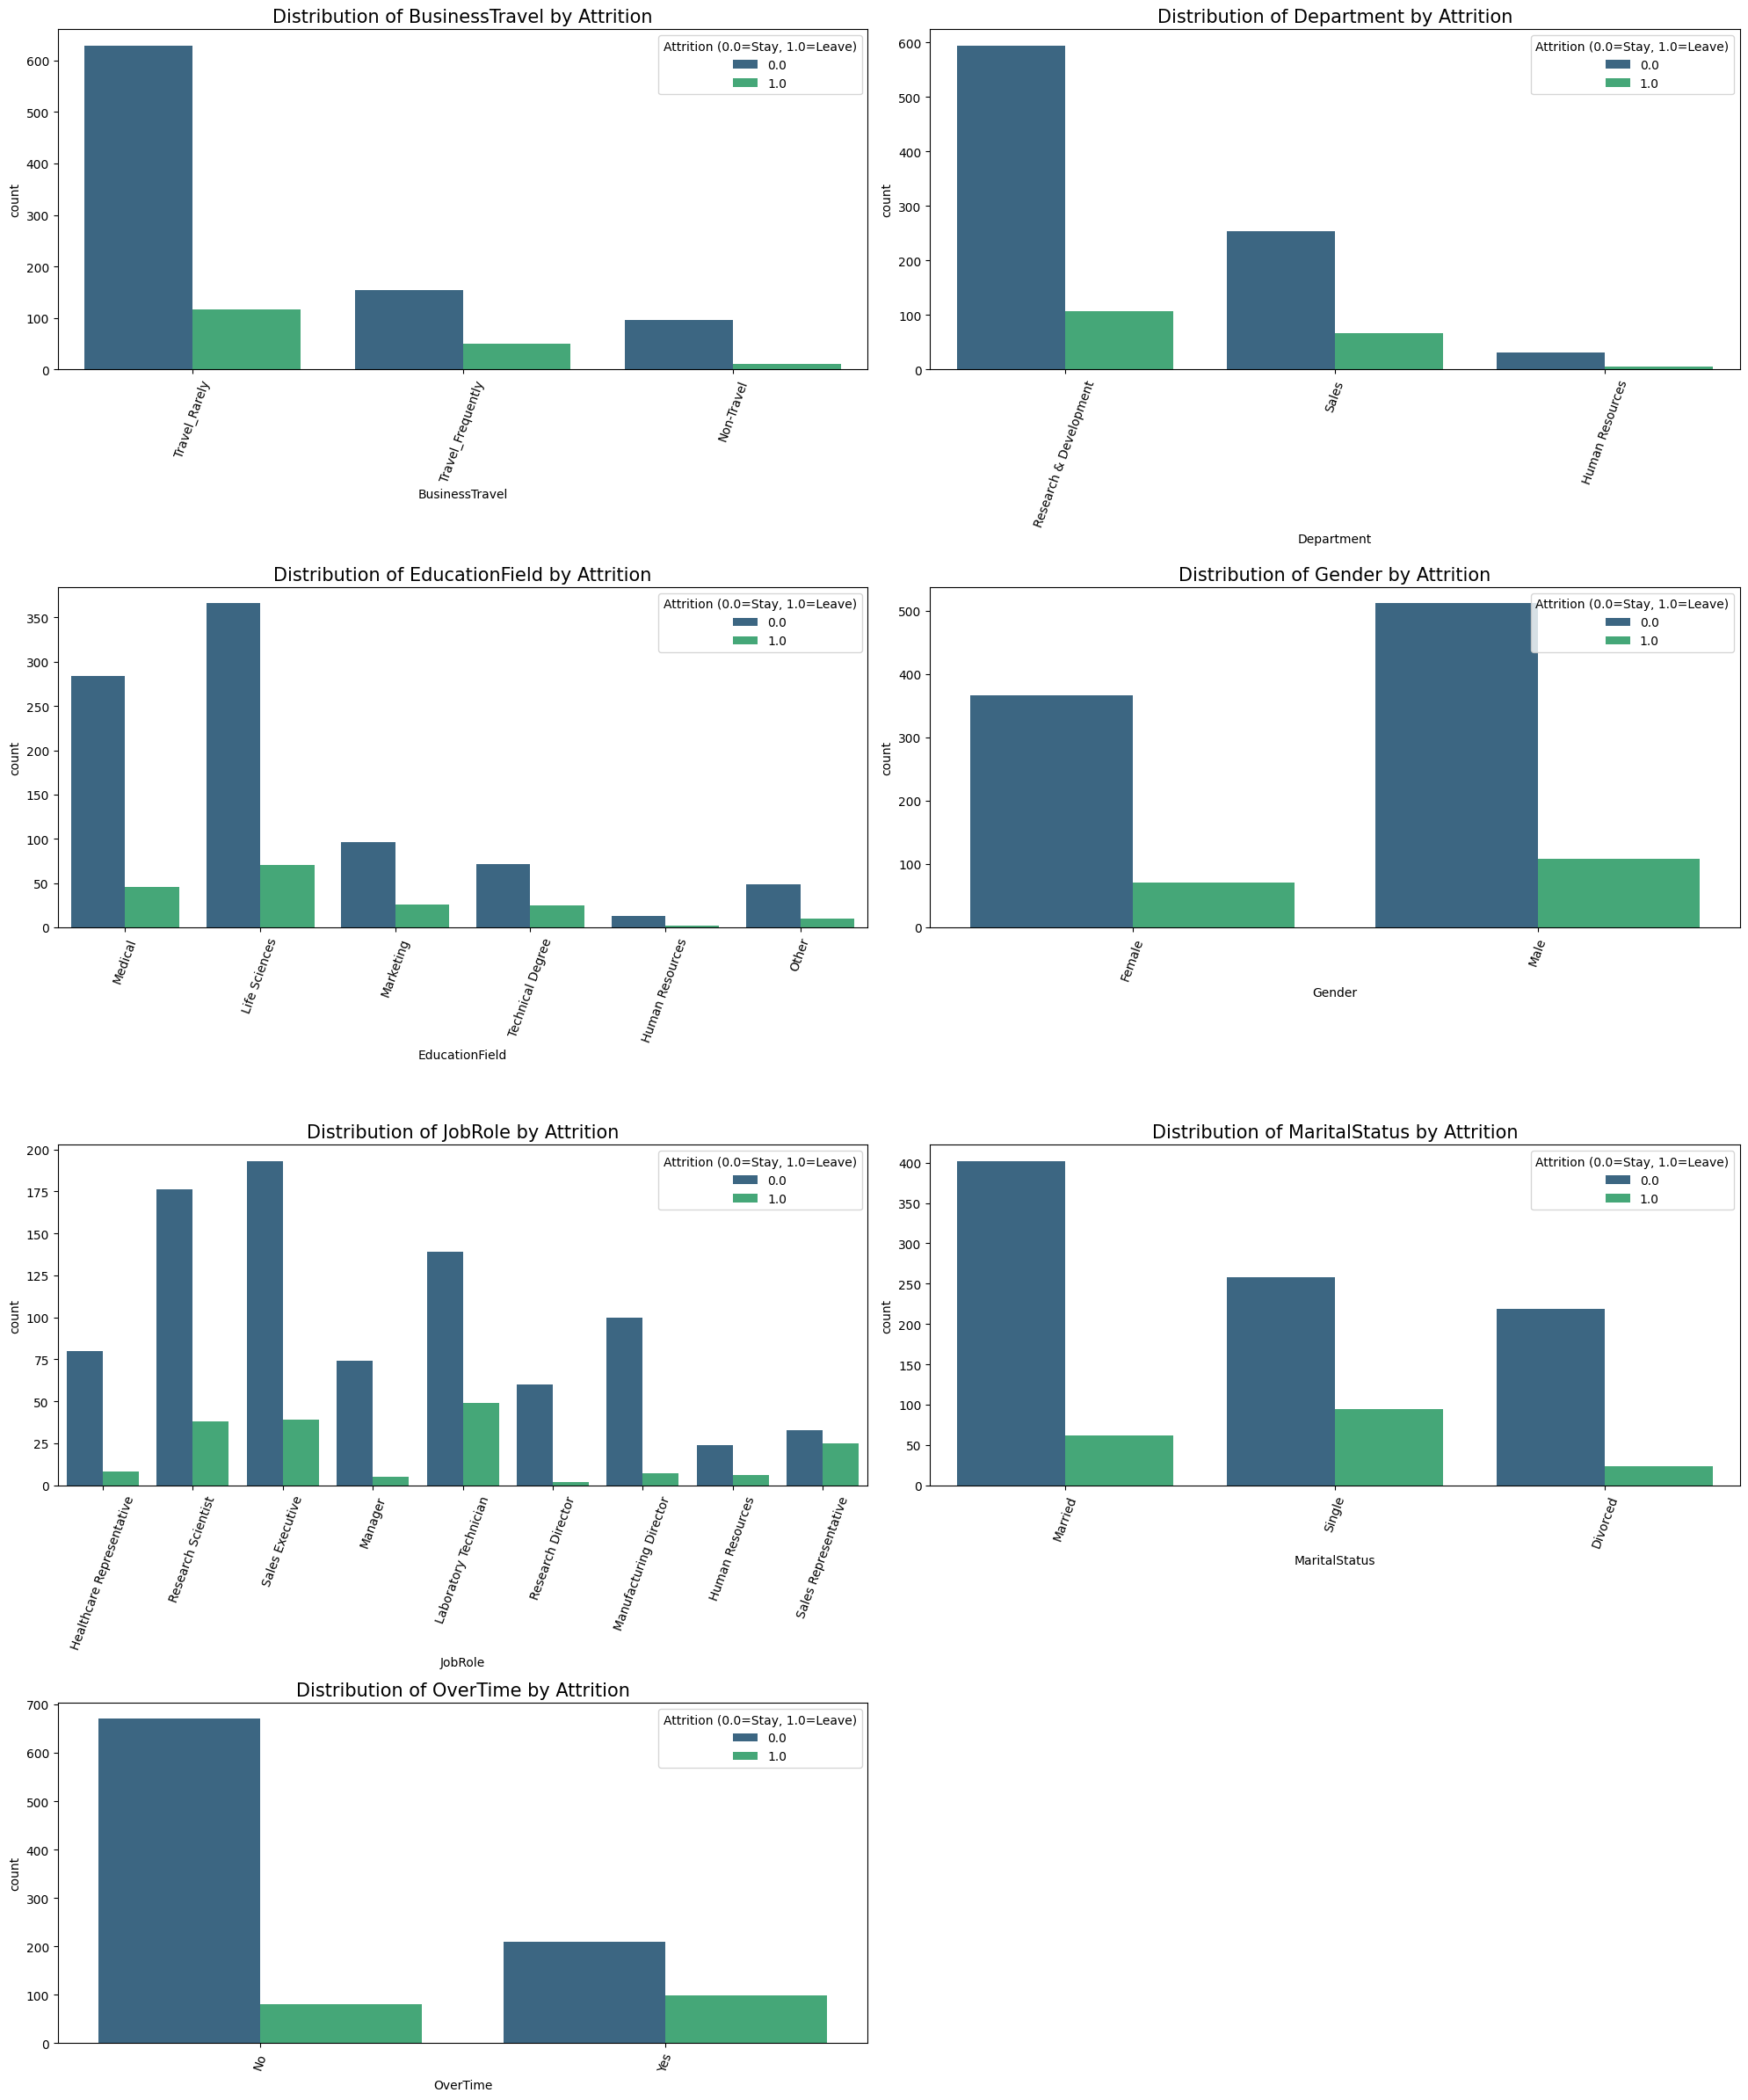

In [16]:
# Mengambil daftar kolom kategorikal (tipe data 'object')
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Menentukan layout grid
cols_per_row = 2
n_cols = len(categorical_cols)
rows = (n_cols // cols_per_row) + (n_cols % cols_per_row > 0)

# Membuat visualisasi
plt.figure(figsize=(20, 6 * rows))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, cols_per_row, i + 1)

    # Menggunakan hue='Attrition' untuk melihat proporsi karyawan yang keluar di setiap kategori
    sns.countplot(data=df_cleaned, x=col, hue='Attrition', palette='viridis')

    plt.title(f'Distribution of {col} by Attrition', fontsize=15)
    plt.xticks(rotation=70)
    plt.legend(title='Attrition (0.0=Stay, 1.0=Leave)', loc='upper right')

    # Catatan:
    # Attrition = 0.0 -> Karyawan masih bekerja (Stay)
    # Attrition = 1.0 -> Karyawan keluar dari perusahaan (Leave)

plt.tight_layout()
plt.show()

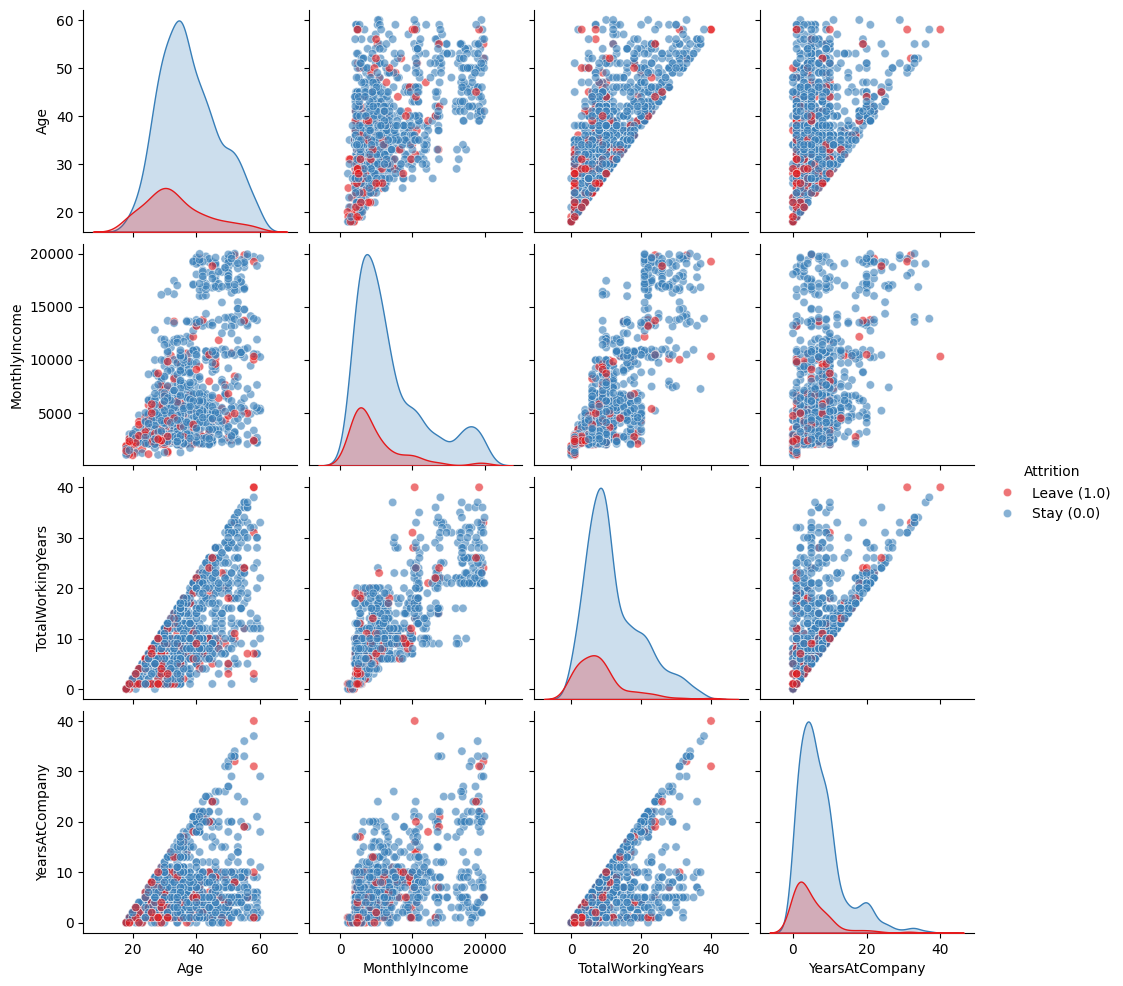

In [17]:
# Pilih fitur yang relevan untuk visualisasi
selected_features = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'Attrition'
]

# Ubah label target 'Attrition' menjadi lebih informatif
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({
    0.0: 'Stay (0.0)',
    1.0: 'Leave (1.0)'
})

# Buat pairplot untuk melihat hubungan antar fitur dengan label Attrition
sns.pairplot(
    df_cleaned[selected_features],
    hue='Attrition',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

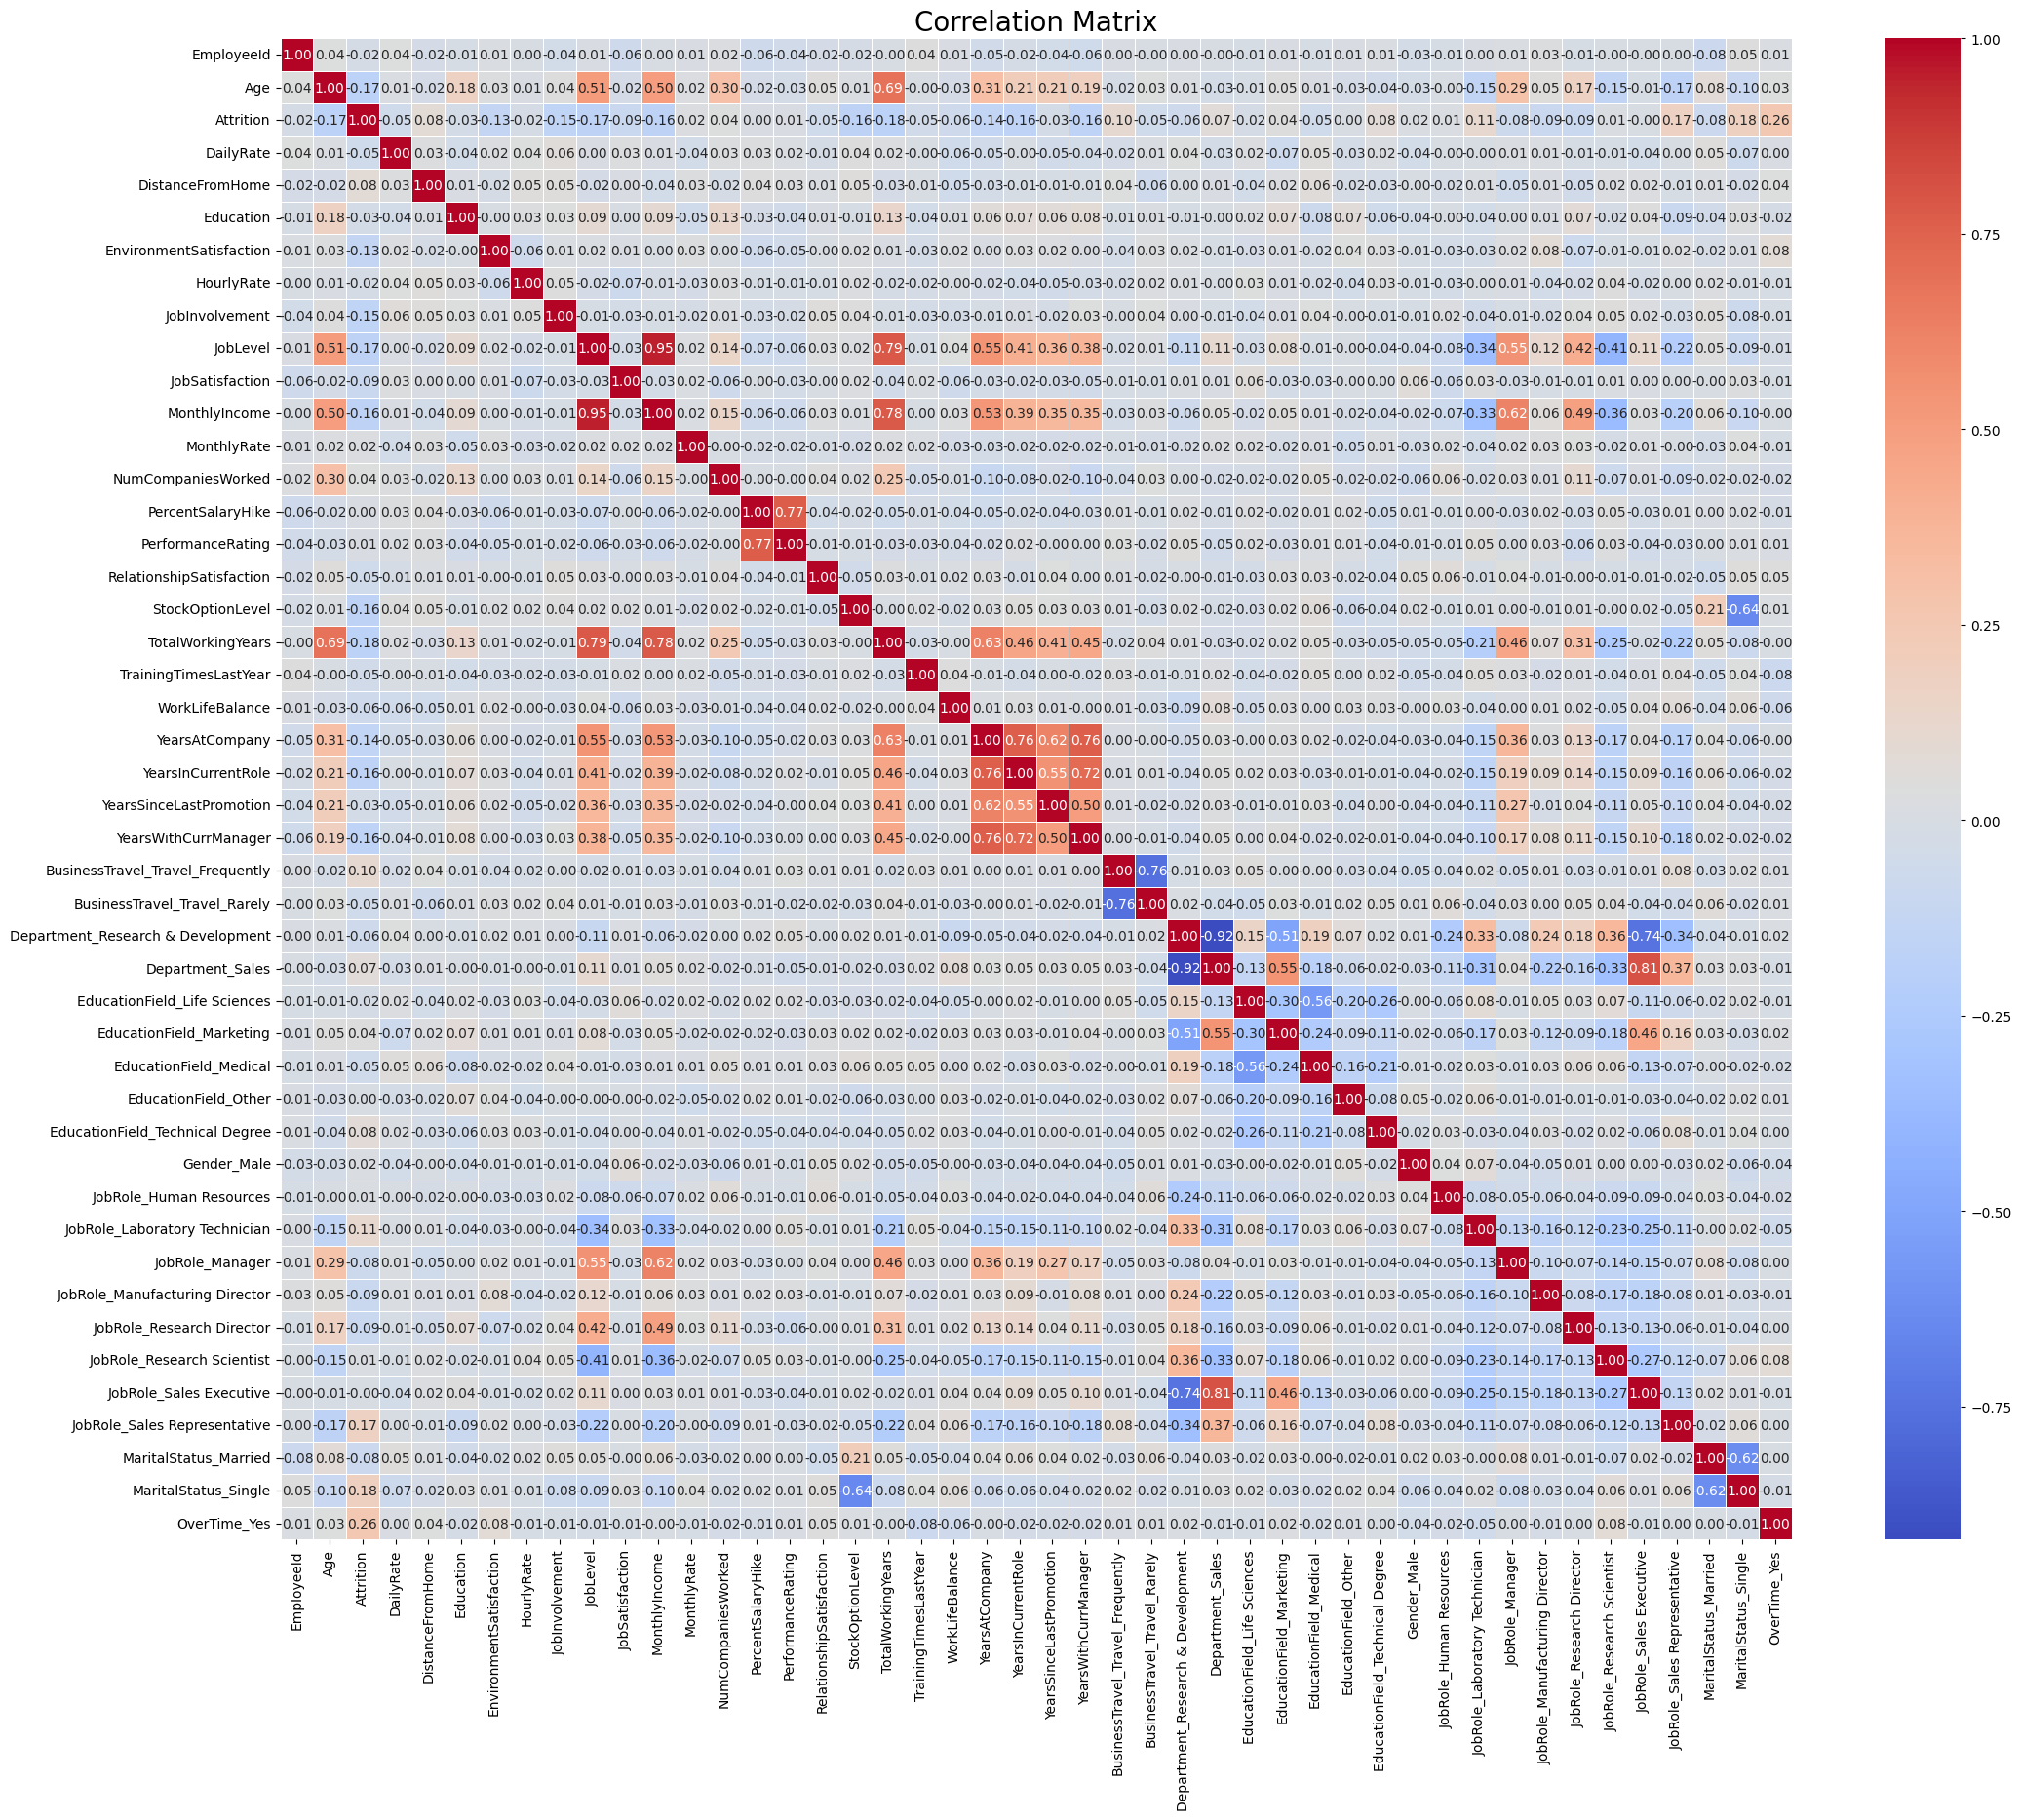

In [18]:
# Pastikan kolom Attrition numerik
if df_cleaned['Attrition'].dtype == 'object':
    df_cleaned['Attrition'] = (
        df_cleaned['Attrition']
        .str.extract(r'(\d+)')
        .astype(int)
    )
else:
    df_cleaned['Attrition'] = df_cleaned['Attrition'].astype(int)

# Encode seluruh fitur kategorikal (termasuk fitur non-numerik)
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# Hitung matriks korelasi
correlation_matrix = df_encoded.corr()

# Plot heatmap korelasi
plt.figure(figsize=(25, 20))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Matrix', fontsize=20)
plt.show()

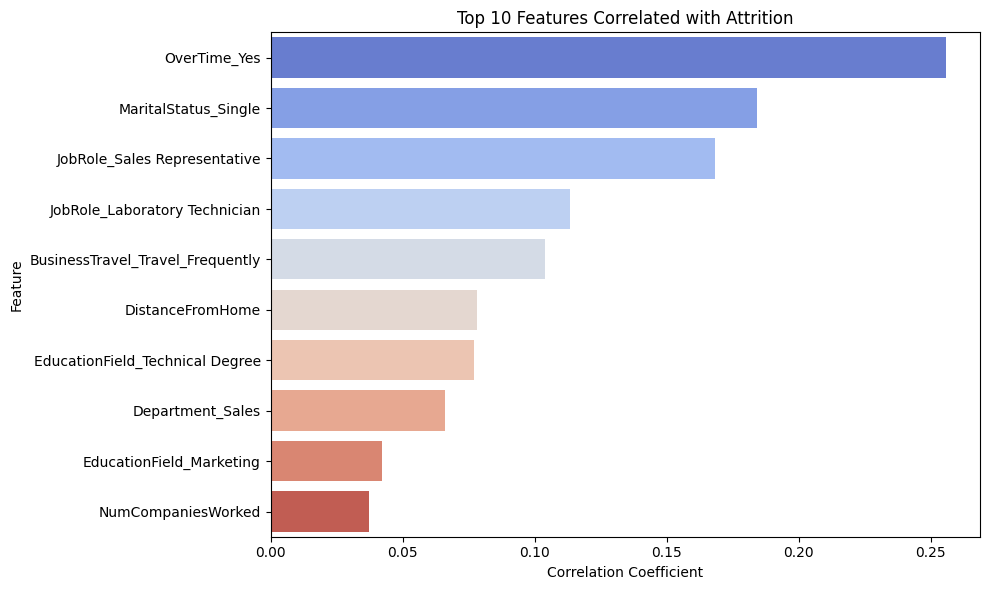

In [19]:
# Hitung korelasi fitur terhadap Attrition
attrition_corr = correlation_matrix['Attrition'].sort_values(ascending=False)

# Ambil 10 fitur teratas (selain Attrition itu sendiri)
top_10_factors = attrition_corr.drop('Attrition').head(10)

# Visualisasi dengan barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_factors.values,
    y=top_10_factors.index,
    palette='coolwarm'
)
plt.title('Top 10 Features Correlated with Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [20]:
df_top_10 = top_10_factors.reset_index()
df_top_10.columns = ['Feature', 'Correlation_Coefficient']

df_top_10['Correlation_Coefficient'] = df_top_10['Correlation_Coefficient'].round(3)

df_top_10.to_csv('top_10_attrition_factors.csv', index=False)

In [21]:
# Label Encoding untuk kolom kategorikal (object)
le = LabelEncoder()
for col in df_cleaned.select_dtypes(include=['object']).columns:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

print("\nData after Label Encoding:")
print(df_cleaned.info())

# One-Hot Encoding
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

print("\nData after One-Hot Encoding:")
print(df_encoded.head())


Data after Label Encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   EmployeeId                1058 non-null   int64
 1   Age                       1058 non-null   int64
 2   Attrition                 1058 non-null   int64
 3   BusinessTravel            1058 non-null   int64
 4   DailyRate                 1058 non-null   int64
 5   Department                1058 non-null   int64
 6   DistanceFromHome          1058 non-null   int64
 7   Education                 1058 non-null   int64
 8   EducationField            1058 non-null   int64
 9   EnvironmentSatisfaction   1058 non-null   int64
 10  Gender                    1058 non-null   int64
 11  HourlyRate                1058 non-null   int64
 12  JobInvolvement            1058 non-null   int64
 13  JobLevel                  1058 non-null   int64
 14  JobRole          

In [22]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

In [23]:
# Scaling dilakukan pada seluruh X sebelum split
scaler = StandardScaler()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Class distribution before SMOTE:\n{y_train.value_counts(normalize=True)}")

Class distribution before SMOTE:
Attrition
0    0.831081
1    0.168919
Name: proportion, dtype: float64


In [25]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nClass distribution after SMOTE:\n{y_resampled.value_counts(normalize=True)}")


Class distribution after SMOTE:
Attrition
1    0.5
0    0.5
Name: proportion, dtype: float64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.3,
    random_state=42,
    stratify=y_resampled
)

## Modeling

In [27]:
# Random Forest Tuning
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
model_rf = grid_rf.best_estimator_

# XGBoost Tuning
param_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), param_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
model_xgb = grid_xgb.best_estimator_

# SVM Tuning
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'probability': [True] # Wajib True untuk menghitung ROC AUC
}
grid_svm = GridSearchCV(SVC(random_state=42), param_svm, cv=5, scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train, y_train)
model_svm = grid_svm.best_estimator_

print("Tuning completed for all three models.")

Tuning completed for all three models.


## Evaluation


==================== Random Forest ====================
              precision    recall  f1-score   support

    0 (Stay)       0.93      0.96      0.95       264
   1 (Leave)       0.96      0.93      0.94       264

    accuracy                           0.95       528
   macro avg       0.95      0.95      0.95       528
weighted avg       0.95      0.95      0.95       528

ROC AUC Score: 0.9827


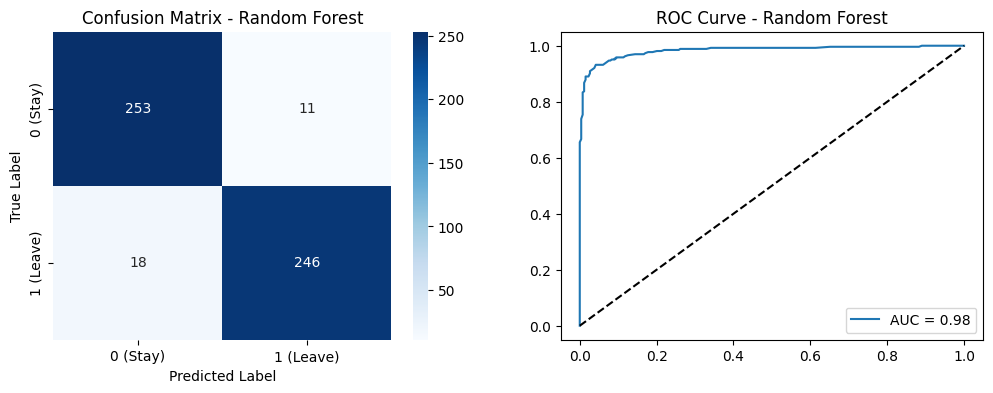


==================== XGBoost ====================
              precision    recall  f1-score   support

    0 (Stay)       0.92      0.92      0.92       264
   1 (Leave)       0.92      0.92      0.92       264

    accuracy                           0.92       528
   macro avg       0.92      0.92      0.92       528
weighted avg       0.92      0.92      0.92       528

ROC AUC Score: 0.9744


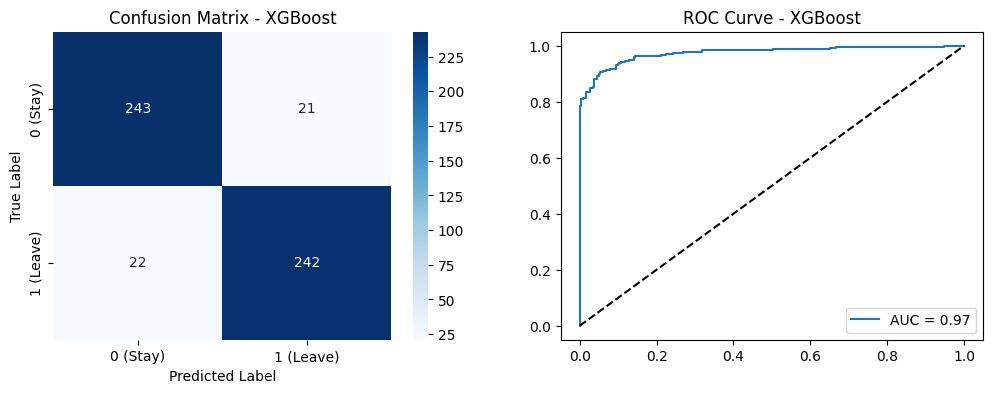


==================== SVM ====================
              precision    recall  f1-score   support

    0 (Stay)       1.00      0.87      0.93       264
   1 (Leave)       0.88      1.00      0.94       264

    accuracy                           0.93       528
   macro avg       0.94      0.93      0.93       528
weighted avg       0.94      0.93      0.93       528

ROC AUC Score: 0.9929


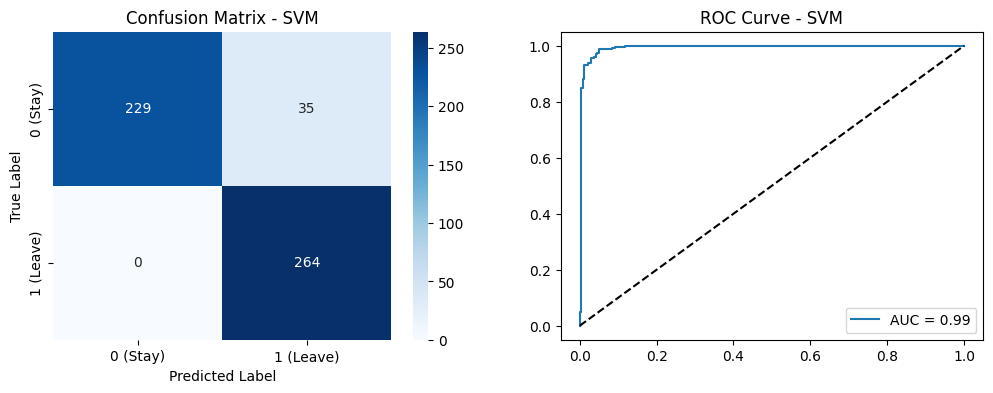

In [28]:
def evaluate_model(model, name, X_test, y_test):
    print(f"\n{'='*20} {name} {'='*20}")

    # Prediksi
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print(classification_report(y_test, y_pred, target_names=['0 (Stay)', '1 (Leave)']))

    # ROC AUC Score
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"ROC AUC Score: {auc_score:.4f}")

    # Visualisasi
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax[0],
        xticklabels=['0 (Stay)', '1 (Leave)'],
        yticklabels=['0 (Stay)', '1 (Leave)']
    )
    ax[0].set_title(f'Confusion Matrix - {name}')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f'ROC Curve - {name}')
    ax[1].legend()
    plt.show()

    return auc_score

# Menjalankan evaluasi satu per satu
auc_rf = evaluate_model(model_rf, "Random Forest", X_test, y_test)
auc_xgb = evaluate_model(model_xgb, "XGBoost", X_test, y_test)
auc_svm = evaluate_model(model_svm, "SVM", X_test, y_test)

In [29]:
# Tentukan Model Terbaik
results = {
    'Random Forest': (model_rf, accuracy_score(y_test, model_rf.predict(X_test)), auc_rf),
    'XGBoost': (model_xgb, accuracy_score(y_test, model_xgb.predict(X_test)), auc_xgb),
    'SVM': (model_svm, accuracy_score(y_test, model_svm.predict(X_test)), auc_svm)
}

# Tentukan model terbaik berdasarkan Accuracy
best_model_name = max(results, key=lambda x: results[x][1])
best_model_obj = results[best_model_name][0]
best_model_acc = results[best_model_name][1]
best_model_auc = results[best_model_name][2]

# Cetak hasil
print(f"\nThe best model is: {best_model_name}")
print(f"Accuracy: {best_model_acc:.4f}")
print(f"AUC: {best_model_auc:.4f}")

# Simpan Model Terbaik ke file .pkl
joblib.dump(best_model_obj, 'best_attrition_model.pkl')
print(f"Model {best_model_name} has been successfully saved as 'best_attrition_model.pkl'")

# Simpan Scaler ke file .pkl
joblib.dump(scaler, 'scaler.pkl')
print("StandardScaler has been successfully saved as 'scaler.pkl'")


The best model is: Random Forest
Accuracy: 0.9451
AUC: 0.9827
Model Random Forest has been successfully saved as 'best_attrition_model.pkl'
StandardScaler has been successfully saved as 'scaler.pkl'


In [30]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.3
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.2.2.0.48.1
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.33.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==4.0.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==7.0.0
catalogue==2.0.10
certifi==2026.1.4
cffi